In [1]:
import polars as pl
import pandas as pd
import os
RAW_DIR = r"E:\NidaanKosha-100k\data\raw"
files = [os.path.join(RAW_DIR, f) for f in os.listdir(RAW_DIR) if f.endswith(".parquet")]
print("Parquet files found:")
for f in files:
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {os.path.basename(f)} - {size_mb:.1f} MB")

Parquet files found:
  train-00000-of-00002.parquet - 87.8 MB
  train-00001-of-00002.parquet - 87.8 MB


In [2]:
# Read both parquet files with polars (fast, low memory)
dfs = [pl.read_parquet(f) for f in files]
df = pl.concat(dfs)
print(f"Total rows: {df.height:,}")
print(f"Total columns: {df.width}")
print(f"\nSchema:")
for name, dtype in df.schema.items():
    print(f"  {name:20s} {dtype}")
print(f"\nFirst 3 rows:")
print(df.head(3))

Total rows: 6,844,304
Total columns: 9

Schema:
  document_id          String
  age                  Int64
  gender               String
  test_name            String
  display_ranges       String
  value                String
  unit                 String
  specimen             String
  loinc                String

First 3 rows:
shape: (3, 9)
┌─────────────────────────────────┬─────┬────────┬─────────────────────────────────┬───┬──────────┬───────┬──────────┬────────┐
│ document_id                     ┆ age ┆ gender ┆ test_name                       ┆ … ┆ value    ┆ unit  ┆ specimen ┆ loinc  │
│ ---                             ┆ --- ┆ ---    ┆ ---                             ┆   ┆ ---      ┆ ---   ┆ ---      ┆ ---    │
│ str                             ┆ i64 ┆ str    ┆ str                             ┆   ┆ str      ┆ str   ┆ str      ┆ str    │
╞═════════════════════════════════╪═════╪════════╪═════════════════════════════════╪═══╪══════════╪═══════╪══════════╪════════╡
│ a1ce7f03fca1

In [3]:
print(f"Total rows: {df.height:,}")
print(f"Unique document_ids (patients): {df['document_id'].n_unique():,}")
print(f"Unique LOINC codes: {df['loinc'].n_unique():,}")
print(f"Unique test_names: {df['test_name'].n_unique():,}")
print(f"Unique genders: {df['gender'].unique().to_list()}")
print(f"\nNull counts per column:")
nulls = df.null_count()
for col in df.columns:
    n = nulls[col][0]
    pct = n / df.height * 100
    print(f"  {col:20s} {n:>12,} ({pct:5.2f}%)")
print(f"\nTop 10 LOINC codes by frequency:")
print(df.group_by("loinc").len().sort("len", descending=True).head(10))

Total rows: 6,844,304
Unique document_ids (patients): 100,000
Unique LOINC codes: 582
Unique test_names: 64,328
Unique genders: ['male', 'female']

Null counts per column:
  document_id                     0 ( 0.00%)
  age                             0 ( 0.00%)
  gender                          0 ( 0.00%)
  test_name                       3 ( 0.00%)
  display_ranges            744,316 (10.87%)
  value                           0 ( 0.00%)
  unit                    1,011,831 (14.78%)
  specimen                  400,726 ( 5.85%)
  loinc                     495,826 ( 7.24%)

Top 10 LOINC codes by frequency:
shape: (10, 2)
┌─────────┬────────┐
│ loinc   ┆ len    │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ null    ┆ 495826 │
│ 2093-3  ┆ 99830  │
│ 718-7   ┆ 99722  │
│ 20570-8 ┆ 98325  │
│ 26453-1 ┆ 98029  │
│ 26464-8 ┆ 97788  │
│ 26515-7 ┆ 97631  │
│ 30428-7 ┆ 97458  │
│ 26478-8 ┆ 97364  │
│ 2571-8  ┆ 97049  │
└─────────┴────────┘


In [4]:
from dotenv import load_dotenv
import os
import sqlalchemy
load_dotenv()
DB_USER = os.getenv("MYSQL_USER")
DB_PASS = os.getenv("MYSQL_PASSWORD")
DB_HOST = os.getenv("MYSQL_HOST")
DB_PORT = os.getenv("MYSQL_PORT")
DB_NAME = os.getenv("MYSQL_DATABASE")
# Build connection URL
db_url = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = sqlalchemy.create_engine(db_url, echo=False)
# Drop tables in reverse dependency order (for clean re-runs)
with engine.begin() as conn:
    conn.execute(sqlalchemy.text("SET FOREIGN_KEY_CHECKS=0"))
    conn.execute(sqlalchemy.text("DROP TABLE IF EXISTS lab_results"))
    conn.execute(sqlalchemy.text("DROP TABLE IF EXISTS loinc_dictionary"))
    conn.execute(sqlalchemy.text("DROP TABLE IF EXISTS patients"))
    conn.execute(sqlalchemy.text("SET FOREIGN_KEY_CHECKS=1"))
    print("Dropped old tables (if any)")
# DDL — schema design
ddl = """
CREATE TABLE patients (
    document_id   VARCHAR(32)  NOT NULL,
    age           TINYINT UNSIGNED NOT NULL,
    gender        VARCHAR(10)  NOT NULL,
    age_group     VARCHAR(10)  NOT NULL,
    PRIMARY KEY (document_id),
    INDEX idx_gender (gender),
    INDEX idx_age_group (age_group)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
CREATE TABLE loinc_dictionary (
    loinc                VARCHAR(20)  NOT NULL,
    canonical_test_name  VARCHAR(200) NOT NULL,
    specimen_default     VARCHAR(50),
    category             VARCHAR(50),
    PRIMARY KEY (loinc),
    INDEX idx_category (category)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
CREATE TABLE lab_results (
    id             BIGINT       NOT NULL AUTO_INCREMENT,
    document_id    VARCHAR(32)  NOT NULL,
    loinc          VARCHAR(20),
    test_name_raw  VARCHAR(200) NOT NULL,
    value_raw      VARCHAR(255) NOT NULL,
    value_num      DECIMAL(15,5),
    is_numeric     TINYINT(1)   NOT NULL DEFAULT 0,
    unit           VARCHAR(20),
    specimen       VARCHAR(50),
    display_range  VARCHAR(100),
    PRIMARY KEY (id),
    INDEX idx_doc (document_id),
    INDEX idx_loinc (loinc),
    INDEX idx_doc_loinc (document_id, loinc)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""
# Execute each statement
for stmt in [s.strip() for s in ddl.split(";") if s.strip()]:
    with engine.begin() as conn:
        conn.execute(sqlalchemy.text(stmt))
# Verify
with engine.connect() as conn:
    tables = conn.execute(sqlalchemy.text("SHOW TABLES")).fetchall()
    print("Tables in nidaan_kosha database:")
    for t in tables:
        print(f"  {t[0]}")
engine.dispose()

Dropped old tables (if any)
Tables in nidaan_kosha database:
  lab_results
  loinc_dictionary
  patients


In [5]:
import polars as pl
# ---- 1. Build PATIENTS dataframe ----
patients = (
    df.select(["document_id", "age", "gender"])
    .unique(subset=["document_id"])
    .with_columns([
        pl.when(pl.col("age") < 30).then(pl.lit("18-29"))
        .when(pl.col("age") < 45).then(pl.lit("30-44"))
        .when(pl.col("age") < 60).then(pl.lit("45-59"))
        .when(pl.col("age") < 75).then(pl.lit("60-74"))
        .otherwise(pl.lit("75+"))
        .alias("age_group")
    ])
    .sort("document_id")
)
print(f"Patients to insert: {patients.height:,}")
print(patients.head(5))
# ---- 2. Build LOINC dictionary with clinical category mapping ----
LOINC_CATEGORY = {
    # CBC
    "718-7": ("Hemoglobin", "blood", "cbc"),
    "20570-8": ("Hematocrit", "blood", "cbc"),
    "26453-1": ("RBC Count", "blood", "cbc"),
    "26464-8": ("WBC Count", "blood", "cbc"),
    "26515-7": ("Platelet Count", "blood", "cbc"),
    "30428-7": ("MCV", "blood", "cbc"),
    "26478-8": ("Lymphocyte %", "blood", "cbc"),
    "26474-7": ("Lymphocyte Absolute", "blood", "cbc"),
    "26499-4": ("Neutrophil Absolute", "blood", "cbc"),
    "26450-7": ("Eosinophil %", "blood", "cbc"),
    "26449-9": ("Eosinophil Absolute", "blood", "cbc"),
    "26485-3": ("Monocytes %", "blood", "cbc"),
    "26484-6": ("Monocytes Absolute", "blood", "cbc"),
    "30180-4": ("Basophils %", "blood", "cbc"),
    "26444-0": ("Basophils Absolute", "blood", "cbc"),
    "28539-5": ("MCH", "blood", "cbc"),
    "28540-3": ("MCHC", "blood", "cbc"),
    "30385-9": ("RDW CV", "blood", "cbc"),
    "30384-2": ("RDW SD", "blood", "cbc"),
    "28542-9": ("MPV", "blood", "cbc"),
    "48386-7": ("P-LCR", "blood", "cbc"),
    "51637-7": ("Plateletcrit", "blood", "cbc"),
    "30341-2": ("ESR", "blood", "cbc"),
    "53797-7": ("Neutrophils %", "blood", "cbc"),
    "19048-8": ("NRBC %", "blood", "cbc"),
    "51584-1": ("Immature Granulocytes", "blood", "cbc"),
    # Lipid
    "2093-3": ("Total Cholesterol", "serum", "lipid"),
    "2571-8": ("Triglycerides", "serum", "lipid"),
    "2085-9": ("HDL Cholesterol", "serum", "lipid"),
    "2089-1": ("LDL Cholesterol", "serum", "lipid"),
    "13457-7": ("Cholesterol Panels", "serum", "lipid"),
    "43396-1": ("Non-HDL Cholesterol", "serum", "lipid"),
    "9830-1": ("TC/HDL Ratio", "serum", "lipid"),
    "11054-4": ("LDL/HDL Ratio", "serum", "lipid"),
    "2091-7": ("VLDL Cholesterol", "serum", "lipid"),
    # Diabetes
    "4548-4": ("HbA1c", "blood", "diabetes"),
    "27353-2": ("eAG (Avg Glucose)", "blood", "diabetes"),
    "2345-7": ("Glucose", "serum", "diabetes"),
    "2344-0": ("Glucose Challenge", "serum", "diabetes"),
    # Liver
    "1742-6": ("ALT (SGPT)", "serum", "liver"),
    "1920-8": ("AST (SGOT)", "serum", "liver"),
    "1975-2": ("Bilirubin Total", "serum", "liver"),
    "1968-7": ("Bilirubin Direct", "serum", "liver"),
    "1971-1": ("Bilirubin Indirect", "serum", "liver"),
    "1751-7": ("Albumin", "serum", "liver"),
    "2885-2": ("Total Protein", "serum", "liver"),
    "6768-6": ("Alkaline Phosphatase", "serum", "liver"),
    "2324-2": ("GGT", "serum", "liver"),
    "1759-0": ("A/G Ratio", "serum", "liver"),
    "2336-6": ("Globulin", "serum", "liver"),
    # Kidney
    "2160-0": ("Creatinine", "serum", "kidney"),
    "3094-0": ("BUN", "serum", "kidney"),
    "3084-1": ("Uric Acid", "serum", "kidney"),
    "69405-9": ("eGFR", "serum", "kidney"),
    "3097-3": ("BUN/Creatinine Ratio", "serum", "kidney"),
    "17861-6": ("Calcium", "serum", "kidney"),
    # Thyroid
    "3016-3": ("TSH", "serum", "thyroid"),
    "3026-2": ("Total T4", "serum", "thyroid"),
    "3053-6": ("Total T3", "serum", "thyroid"),
    # Electrolytes
    "1963-8": ("Bicarbonate", "serum", "electrolytes"),
    "2075-0": ("Chloride", "serum", "electrolytes"),
    "2951-2": ("Sodium", "serum", "electrolytes"),
    "2823-3": ("Potassium", "serum", "electrolytes"),
    # Iron
    "2498-4": ("Iron", "serum", "iron"),
    "2500-7": ("TIBC", "serum", "iron"),
    "2502-3": ("Transferrin Saturation", "serum", "iron"),
    "2276-4": ("Ferritin", "serum", "iron"),
    # Vitamins
    "2132-9": ("Vitamin B12", "serum", "vitamins"),
    "62292-8": ("Vitamin D 25-OH", "serum", "vitamins"),
    "1754-1": ("Vitamin B12 (alt)", "serum", "vitamins"),
}
# Build loinc dict dataframe
loinc_df = pl.DataFrame({
    "loinc": list(LOINC_CATEGORY.keys()),
    "canonical_test_name": [v[0] for v in LOINC_CATEGORY.values()],
    "specimen_default": [v[1] for v in LOINC_CATEGORY.values()],
    "category": [v[2] for v in LOINC_CATEGORY.values()],
})
print(f"\nLOINC dictionary rows: {loinc_df.height}")
print(f"Categories: {loinc_df['category'].value_counts().sort('count', descending=True)}")

Patients to insert: 100,000
shape: (5, 4)
┌─────────────────────────────────┬─────┬────────┬───────────┐
│ document_id                     ┆ age ┆ gender ┆ age_group │
│ ---                             ┆ --- ┆ ---    ┆ ---       │
│ str                             ┆ i64 ┆ str    ┆ str       │
╞═════════════════════════════════╪═════╪════════╪═══════════╡
│ 0000dc1043b556f847b88a34a1875b… ┆ 45  ┆ female ┆ 45-59     │
│ 000219ef567ad65827350691e27760… ┆ 36  ┆ male   ┆ 30-44     │
│ 00035a9874991a7860f448275b54f0… ┆ 26  ┆ female ┆ 18-29     │
│ 00037a26c47df4123bcaeda56a0e13… ┆ 19  ┆ male   ┆ 18-29     │
│ 0003b1d0154a792cf85a281ebd74c9… ┆ 57  ┆ female ┆ 45-59     │
└─────────────────────────────────┴─────┴────────┴───────────┘

LOINC dictionary rows: 70
Categories: shape: (9, 2)
┌──────────────┬───────┐
│ category     ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ cbc          ┆ 26    │
│ liver        ┆ 11    │
│ lipid        ┆ 9     │
│ kidney    

In [6]:
import pandas as pd
import sqlalchemy
engine = sqlalchemy.create_engine(db_url)
# Insert patients
patients_pd = patients.to_pandas()
patients_pd.to_sql("patients", engine, if_exists="append", index=False, chunksize=5000, method=None)
print(f"Inserted {len(patients_pd):,} patient rows")
# Insert loinc_dictionary
loinc_pd = loinc_df.to_pandas()
loinc_pd.to_sql("loinc_dictionary", engine, if_exists="append", index=False, chunksize=1000)
print(f"Inserted {len(loinc_pd):,} loinc dictionary rows")
# Verify
with engine.connect() as conn:
    p_count = conn.execute(sqlalchemy.text("SELECT COUNT(*) FROM patients")).scalar()
    l_count = conn.execute(sqlalchemy.text("SELECT COUNT(*) FROM loinc_dictionary")).scalar()
    print(f"\nVerification:")
    print(f"  patients table: {p_count:,} rows")
    print(f"  loinc_dictionary table: {l_count:,} rows")
engine.dispose()

Inserted 100,000 patient rows
Inserted 70 loinc dictionary rows

Verification:
  patients table: 100,000 rows
  loinc_dictionary table: 70 rows


In [7]:
import polars as pl
import sqlalchemy
from tqdm.notebook import tqdm
import time
# ---- Parse values in polars ----
df_clean = df.with_columns([
    pl.col("value").alias("value_raw"),
    pl.col("test_name").alias("test_name_raw"),
    pl.col("display_ranges").alias("display_range"),
    # Parse numeric — strict=False returns null for non-numeric
    pl.col("value").cast(pl.Float64, strict=False).alias("value_num"),
    # is_numeric: 1 only for clean numeric values
    pl.col("value").str.contains(r"^[+-]?\d+(\.\d+)?$").cast(pl.Int8).alias("is_numeric"),
]).select([
    "document_id", "loinc", "test_name_raw", "value_raw", "value_num",
    "is_numeric", "unit", "specimen", "display_range"
])
# Check parsing quality
total = df_clean.height
n_numeric = df_clean.filter(pl.col("is_numeric") == 1).height
n_null_loinc = df_clean.filter(pl.col("loinc").is_null()).height
print(f"Total rows: {total:,}")
print(f"Numeric values: {n_numeric:,} ({n_numeric/total*100:.1f}%)")
print(f"Null LOINC: {n_null_loinc:,} ({n_null_loinc/total*100:.1f}%)")
print(f"Non-numeric samples:")
print(df_clean.filter(pl.col("is_numeric") == 0).select("value_raw").head(10))

Total rows: 6,844,304
Numeric values: 5,778,236 (84.4%)
Null LOINC: 495,826 (7.2%)
Non-numeric samples:
shape: (10, 1)
┌─────────────┐
│ value_raw   │
│ ---         │
│ str         │
╞═════════════╡
│ nil         │
│ nil         │
│ Absent      │
│ Absent      │
│ Negative    │
│ Negative    │
│ Absent      │
│ Pale yellow │
│ Absent      │
│ 1-2         │
└─────────────┘


In [11]:
# Check actual max length
print(f"Max display_range length: {df_clean['display_range'].str.len_chars().max()}")
print(f"Max test_name_raw length: {df_clean['test_name_raw'].str.len_chars().max()}")
print(f"Max value_raw length: {df_clean['value_raw'].str.len_chars().max()}")
print(f"Max unit length: {df_clean['unit'].str.len_chars().max()}")
print(f"Max specimen length: {df_clean['specimen'].str.len_chars().max()}")
print(f"Max document_id length: {df_clean['document_id'].str.len_chars().max()}")

Max display_range length: 662
Max test_name_raw length: 100
Max value_raw length: 255
Max unit length: 15
Max specimen length: 11
Max document_id length: 32


In [12]:
import sqlalchemy
engine = sqlalchemy.create_engine(db_url)
# Drop and recreate lab_results with safer column sizes
with engine.begin() as conn:
    conn.execute(sqlalchemy.text("SET FOREIGN_KEY_CHECKS=0"))
    conn.execute(sqlalchemy.text("DROP TABLE IF EXISTS lab_results"))
    conn.execute(sqlalchemy.text("SET FOREIGN_KEY_CHECKS=1"))
    conn.execute(sqlalchemy.text("""
    CREATE TABLE lab_results (
        id             BIGINT       NOT NULL AUTO_INCREMENT,
        document_id    VARCHAR(64)  NOT NULL,
        loinc          VARCHAR(20),
        test_name_raw  VARCHAR(150) NOT NULL,
        value_raw      TEXT         NOT NULL,
        value_num      DECIMAL(15,5),
        is_numeric     TINYINT(1)   NOT NULL DEFAULT 0,
        unit           VARCHAR(30),
        specimen       VARCHAR(50),
        display_range  VARCHAR(700),
        PRIMARY KEY (id),
        INDEX idx_doc (document_id),
        INDEX idx_loinc (loinc),
        INDEX idx_doc_loinc (document_id, loinc)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
    """))
    print("lab_results recreated with safer column sizes")
engine.dispose()

lab_results recreated with safer column sizes


In [20]:
# import sqlalchemy
# from tqdm.notebook import tqdm
# import time
# engine = sqlalchemy.create_engine(db_url)
# insert_sql = sqlalchemy.text("""
#     INSERT INTO lab_results
#     (document_id, loinc, test_name_raw, value_raw, value_num, is_numeric, unit, specimen, display_range)
#     VALUES (:document_id, :loinc, :test_name_raw, :value_raw, :value_num, :is_numeric, :unit, :specimen, :display_range)
# """)
# CHUNK_SIZE = 50_000
# total_rows = df_clean.height
# n_chunks = (total_rows + CHUNK_SIZE - 1) // CHUNK_SIZE
# print(f"Inserting {total_rows:,} rows in {n_chunks} chunks of {CHUNK_SIZE:,}...\n")
# start = time.time()
# inserted = 0
# try:
#     with engine.begin() as conn:
#         for chunk_idx in tqdm(range(n_chunks), desc="Inserting"):
#             start_idx = chunk_idx * CHUNK_SIZE
#             chunk_df = df_clean.slice(start_idx, CHUNK_SIZE)
#             rows = chunk_df.to_dicts()
#             conn.execute(insert_sql, rows)
#             inserted += len(rows)
# except Exception as e:
#     print(f"\n\nFAILED at row {inserted:,} of {total_rows:,}")
#     print(f"Error: {type(e).__name__}: {str(e)[:500]}")
#     raise
# elapsed = time.time() - start
# print(f"\nDone! {inserted:,} rows in {elapsed:.1f}s ({inserted/elapsed:,.0f} rows/sec)")
# with engine.connect() as conn:
#     count = conn.execute(sqlalchemy.text("SELECT COUNT(*) FROM lab_results")).scalar()
#     print(f"lab_rows count: {count:,}")
# engine.dispose()

In [21]:
# swapped to duckdb as it works directly with parquet files 
# and is way faster than mysql as there's no need to import the data 
# and we can continue working on large dataset in real time.

In [16]:
!pip install duckdb -q
import duckdb
print("duckdb version:", duckdb.__version__)

duckdb version: 1.5.3


In [17]:
import duckdb
# Connect to an in-memory DuckDB (data lives in RAM, lost on close)
# For persistence, use: duckdb.connect("data/nidaan.duckdb")
con = duckdb.connect()
# Test 1: Query parquet directly with SQL — NO LOADING NEEDED
result = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT document_id) AS patients,
        COUNT(DISTINCT loinc) AS loinc_codes
    FROM read_parquet('E:/NidaanKosha-100k/data/raw/*.parquet')
""").fetchdf()
print("Direct parquet query result:")
print(result)
# Test 2: Run a real analytical query (would take MySQL 5+ min to insert, then query)
print("\nTop 10 tests by frequency:")
top_tests = con.execute("""
    SELECT
        test_name,
        loinc,
        COUNT(*) AS n_readings
    FROM read_parquet('E:/NidaanKosha-100k/data/raw/*.parquet')
    GROUP BY test_name, loinc
    ORDER BY n_readings DESC
    LIMIT 10
""").fetchdf()
print(top_tests)

Direct parquet query result:
   total_rows  patients  loinc_codes
0     6844304    100000          581

Top 10 tests by frequency:
        test_name    loinc  n_readings
0       Monocytes  26485-3       60475
1     Lymphocytes  26478-8       59569
2     Eosinophils  26450-7       59212
3       Basophils  30180-4       58108
4     Neutrophils  53797-7       51516
5  Platelet Count  26515-7       48970
6            MCHC  28540-3       43545
7             MCH  28539-5       43219
8      Creatinine   2160-0       42793
9             MCV  30428-7       42734


In [19]:
import duckdb
import pandas as pd
# Connect to a persistent DuckDB file (saved to disk)
con = duckdb.connect("E:/NidaanKosha-100k/data/nidaan.duckdb")
con.execute("INSTALL parquet; LOAD parquet;")
# Register our LOINC dictionary as a virtual table from polars
con.register("loinc_dict", loinc_df.to_pandas())
# Verify
print("LOINC dictionary registered. Categories:")
print(con.execute("SELECT category, COUNT(*) AS n FROM loinc_dict GROUP BY category ORDER BY n DESC").fetchdf())
# Create a view of all lab data joined with the LOINC dictionary
con.execute("""
    CREATE OR REPLACE VIEW v_labs AS
    SELECT
        l.document_id,
        l.age,
        l.gender,
        l.test_name AS test_name_raw,
        l.value,
        l.unit,
        l.specimen,
        l.display_ranges,
        l.loinc,
        d.canonical_test_name,
        d.category
    FROM read_parquet('E:/NidaanKosha-100k/data/raw/*.parquet') l
    LEFT JOIN loinc_dict d ON l.loinc = d.loinc
""")
print("\nView v_labs created (joins parquet + dictionary)")
# Test the view
print("\nSample joined data:")
print(con.execute("SELECT * FROM v_labs WHERE canonical_test_name = 'HbA1c' LIMIT 3").fetchdf())

LOINC dictionary registered. Categories:
       category   n
0           cbc  26
1         liver  11
2         lipid   9
3        kidney   6
4          iron   4
5      diabetes   4
6  electrolytes   4
7       thyroid   3
8      vitamins   3

View v_labs created (joins parquet + dictionary)

Sample joined data:
                        document_id  age  gender  \
0  333b28733c28f5e8ea5a3acc21e768a3   29  female   
1  8d60223963eb5c9bbcad025946f00c51   51  female   
2  b1d9748a64409678998b0bee52c30950   85    male   

                     test_name_raw   value unit specimen  \
0  GLYCOSYLATED HEMOGLOBIN ( HbA1c  5.5400    %    blood   
1                            HbA1c  6.2000    %    blood   
2      HbA1C- Glycated Haemoglobin  5.5000    %    blood   

                                      display_ranges   loinc  \
0  < 6 : non diabetic\n6-7 : good control\n7-8 : ...  4548-4   
1  4.0-5,6% non diabetic\n7-6.4% pre diabetic\n6....  4548-4   
2  non-diabetic: <= 5.6\npre-diabetic: 5.7-6.4

In [22]:
# ---- Disease Cohort Analysis using SQL ----
# Each condition uses standard clinical cutoffs
disease_query = """
WITH patient_demographics AS (
    SELECT DISTINCT document_id, age, gender,
        CASE
            WHEN age < 30 THEN '18-29'
            WHEN age < 45 THEN '30-44'
            WHEN age < 60 THEN '45-59'
            WHEN age < 75 THEN '60-74'
            ELSE '75+'
        END AS age_group
    FROM v_labs
),
patient_labs_wide AS (
    -- Pivot key tests to columns per patient
    SELECT document_id,
        MAX(CASE WHEN loinc = '4548-4'  THEN TRY_CAST(value AS DOUBLE) END) AS hba1c,
        MAX(CASE WHEN loinc = '718-7'   THEN TRY_CAST(value AS DOUBLE) END) AS hemoglobin,
        MAX(CASE WHEN loinc = '2093-3'  THEN TRY_CAST(value AS DOUBLE) END) AS total_cholesterol,
        MAX(CASE WHEN loinc = '2571-8'  THEN TRY_CAST(value AS DOUBLE) END) AS triglycerides,
        MAX(CASE WHEN loinc = '2085-9'  THEN TRY_CAST(value AS DOUBLE) END) AS hdl,
        MAX(CASE WHEN loinc = '2089-1'  THEN TRY_CAST(value AS DOUBLE) END) AS ldl,
        MAX(CASE WHEN loinc = '3016-3'  THEN TRY_CAST(value AS DOUBLE) END) AS tsh,
        MAX(CASE WHEN loinc = '1742-6'  THEN TRY_CAST(value AS DOUBLE) END) AS alt_sgpt,
        MAX(CASE WHEN loinc = '1920-8'  THEN TRY_CAST(value AS DOUBLE) END) AS ast_sgot,
        MAX(CASE WHEN loinc = '2160-0'  THEN TRY_CAST(value AS DOUBLE) END) AS creatinine,
        MAX(CASE WHEN loinc = '69405-9' THEN TRY_CAST(value AS DOUBLE) END) AS egfr
    FROM v_labs
    GROUP BY document_id
),
disease_flags AS (
    SELECT
        pd.document_id, pd.age, pd.gender, pd.age_group,
        pl.hba1c, pl.hemoglobin, pl.total_cholesterol, pl.triglycerides,
        pl.hdl, pl.ldl, pl.tsh, pl.alt_sgpt, pl.ast_sgot, pl.creatinine, pl.egfr,
        -- Anemia: Hb < 12 (F) or < 13 (M)
        CASE WHEN (pd.gender = 'female' AND pl.hemoglobin < 12)
              OR (pd.gender = 'male'   AND pl.hemoglobin < 13)
             THEN 1 ELSE 0 END AS has_anemia,
        -- Diabetes: HbA1c >= 6.5
        CASE WHEN pl.hba1c >= 6.5 THEN 1 ELSE 0 END AS has_diabetes,
        -- Pre-diabetes: 5.7 <= HbA1c < 6.5
        CASE WHEN pl.hba1c >= 5.7 AND pl.hba1c < 6.5 THEN 1 ELSE 0 END AS has_prediabetes,
        -- High Cholesterol: total >= 200
        CASE WHEN pl.total_cholesterol >= 200 THEN 1 ELSE 0 END AS has_high_cholesterol,
        -- High Triglycerides: >= 150
        CASE WHEN pl.triglycerides >= 150 THEN 1 ELSE 0 END AS has_high_triglycerides,
        -- Low HDL: < 40 (M) or < 50 (F)
        CASE WHEN (pd.gender = 'female' AND pl.hdl < 50)
              OR (pd.gender = 'male'   AND pl.hdl < 40)
             THEN 1 ELSE 0 END AS has_low_hdl,
        -- High LDL: >= 130
        CASE WHEN pl.ldl >= 130 THEN 1 ELSE 0 END AS has_high_ldl,
        -- Thyroid dysfunction: TSH out of [0.4, 4.0]
        CASE WHEN pl.tsh < 0.4 OR pl.tsh > 4.0 THEN 1 ELSE 0 END AS has_thyroid_disorder,
        -- Liver: ALT > 40 or AST > 40
        CASE WHEN pl.alt_sgpt > 40 OR pl.ast_sgot > 40 THEN 1 ELSE 0 END AS has_liver_issue,
        -- CKD: eGFR < 90
        CASE WHEN pl.egfr < 90 THEN 1 ELSE 0 END AS has_ckd
    FROM patient_demographics pd
    JOIN patient_labs_wide pl ON pd.document_id = pl.document_id
)
SELECT * FROM disease_flags
"""
# Save the disease-cohort table to DuckDB for repeated use
con.execute(f"CREATE OR REPLACE TABLE disease_cohorts AS {disease_query}")
print("disease_cohorts table created")
# Overall prevalence
print("\n=== OVERALL DISEASE PREVALENCE ===")
prevalence = con.execute("""
    SELECT
        COUNT(*) AS total_patients,
        SUM(has_anemia)            AS anemia,
        SUM(has_diabetes)          AS diabetes,
        SUM(has_prediabetes)       AS prediabetes,
        SUM(has_high_cholesterol)  AS high_chol,
        SUM(has_high_triglycerides) AS high_trig,
        SUM(has_low_hdl)           AS low_hdl,
        SUM(has_high_ldl)          AS high_ldl,
        SUM(has_thyroid_disorder)  AS thyroid,
        SUM(has_liver_issue)       AS liver,
        SUM(has_ckd)               AS ckd
    FROM disease_cohorts
""").fetchdf()
print(prevalence.T)  # transpose for readability

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

disease_cohorts table created

=== OVERALL DISEASE PREVALENCE ===
                       0
total_patients  100000.0
anemia           28433.0
diabetes         25177.0
prediabetes      21095.0
high_chol        31164.0
high_trig        39486.0
low_hdl          48391.0
high_ldl         25165.0
thyroid          23575.0
liver            20079.0
ckd              10201.0


=== DISEASE PREVALENCE BY AGE GROUP & GENDER ===

age_group gender  n_patients  pct_anemia  pct_diabetes  pct_high_chol  pct_low_hdl  pct_thyroid  pct_liver  pct_ckd
    18-29 female        4828        36.6           3.6           15.9         59.7         23.6        9.5      1.0
    18-29   male        6338         7.6           5.1           24.6         36.8         15.7       33.7      2.1
    30-44 female       12879        44.1          11.5           27.8         63.1         28.2       11.5      3.7
    30-44   male       20427         9.8          17.9           38.9         42.8         19.2       38.0      4.6
    45-59 female       14148        39.1          29.2           40.0         58.1         30.2       11.8      9.2
    45-59   male       16810        17.8          34.8           32.5         40.6         19.4       23.5     11.2
    60-74 female        9169        43.8          38.4           34.0         54.9         29.3        9.0     19.3
    60-74   male      

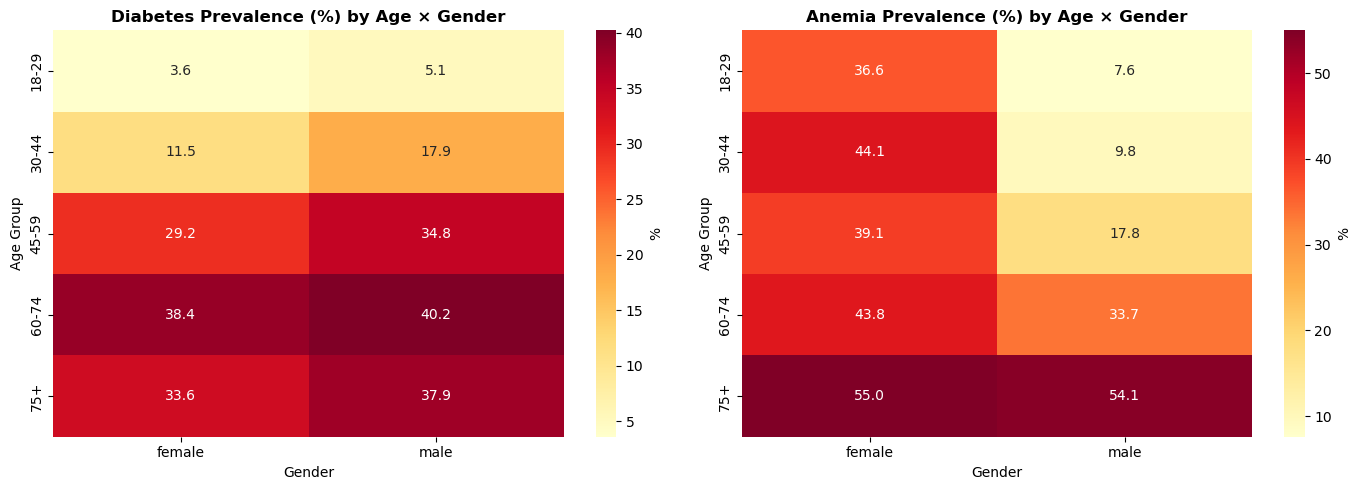


Figure saved: reports/figures/01_prevalence_heatmap.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Disease prevalence by age group and gender
print("=== DISEASE PREVALENCE BY AGE GROUP & GENDER ===\n")
strat = con.execute("""
    SELECT
        age_group,
        gender,
        COUNT(*) AS n_patients,
        ROUND(100.0 * SUM(has_anemia) / COUNT(*), 1)            AS pct_anemia,
        ROUND(100.0 * SUM(has_diabetes) / COUNT(*), 1)          AS pct_diabetes,
        ROUND(100.0 * SUM(has_high_cholesterol) / COUNT(*), 1)  AS pct_high_chol,
        ROUND(100.0 * SUM(has_low_hdl) / COUNT(*), 1)           AS pct_low_hdl,
        ROUND(100.0 * SUM(has_thyroid_disorder) / COUNT(*), 1)  AS pct_thyroid,
        ROUND(100.0 * SUM(has_liver_issue) / COUNT(*), 1)       AS pct_liver,
        ROUND(100.0 * SUM(has_ckd) / COUNT(*), 1)               AS pct_ckd
    FROM disease_cohorts
    GROUP BY age_group, gender
    ORDER BY age_group, gender
""").fetchdf()
print(strat.to_string(index=False))
# Save figure: heatmap of diabetes prevalence by age × gender
pivot = strat.pivot(index="age_group", columns="gender", values="pct_diabetes")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Diabetes heatmap
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "%"})
axes[0].set_title("Diabetes Prevalence (%) by Age × Gender", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Age Group")
# Anemia heatmap
pivot2 = strat.pivot(index="age_group", columns="gender", values="pct_anemia")
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "%"})
axes[1].set_title("Anemia Prevalence (%) by Age × Gender", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Age Group")
plt.tight_layout()
plt.savefig("E:/NidaanKosha-100k/reports/figures/01_prevalence_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nFigure saved: reports/figures/01_prevalence_heatmap.png")

In [26]:
# ---------- Phase 7a: pairwise disease co-occurrence with lift ----------
import duckdb
import pandas as pd
con = duckdb.connect(r"E:/NidaanKosha-100k/data/nidaan.duckdb")
# Auto-detect disease columns (has_* prefix) so this never breaks if names change
cols = con.execute("""
    SELECT column_name FROM information_schema.columns
    WHERE table_name = 'disease_cohorts' AND column_name LIKE 'has_%'
    ORDER BY column_name
""").fetchdf()["column_name"].tolist()
print(f"Found {len(cols)} disease columns: {cols}")
assert len(cols) >= 2, "Need at least 2 disease columns in disease_cohorts"
# Build (display_name, column_name) pairs
DISEASES = [(c.replace("has_", ""), c) for c in cols]
# 1) Marginal prevalence per disease -> temp table
marginal_parts = []
for display, col in DISEASES:
    marginal_parts.append(f"""
        SELECT '{display}' AS condition,
               SUM({col})::INT        AS n_pos,
               COUNT(*)::INT          AS n_total,
               ROUND(100.0*SUM({col})/COUNT(*), 2) AS pct
        FROM disease_cohorts
    """)
con.execute("CREATE OR REPLACE TEMP TABLE marginals AS\n" + "\nUNION ALL\n".join(marginal_parts))
# 2) Pairwise co-occurrence (n, % of a, % of b, confidence, lift)
co_occ_sql = """
    SELECT
        '{a}' AS condition_a,
        '{b}' AS condition_b,
        COUNT(*)::INT AS n_both,
        ROUND(100.0 * COUNT(*) / (SELECT n_total FROM marginals WHERE condition='{a}'), 2) AS pct_of_a,
        ROUND(100.0 * COUNT(*) / (SELECT n_total FROM marginals WHERE condition='{b}'), 2) AS pct_of_b,
        ROUND(1.0 * COUNT(*) / (SELECT n_pos FROM marginals WHERE condition='{a}'), 4)   AS conf_a_given_b,
        ROUND(1.0 * COUNT(*) / (SELECT n_pos FROM marginals WHERE condition='{b}'), 4)   AS conf_b_given_a,
        ROUND(
            (1.0 * COUNT(*)) /
            ( (SELECT n_pos   FROM marginals WHERE condition='{a}')::DOUBLE *
              (SELECT n_pos   FROM marginals WHERE condition='{b}')::DOUBLE /
              (SELECT n_total FROM marginals WHERE condition='{a}')::DOUBLE )
        , 2) AS lift
    FROM disease_cohorts
    WHERE {col_a}=1 AND {col_b}=1
    GROUP BY 1, 2
    ORDER BY n_both DESC
"""
rows = []
for i, (a_name, a_col) in enumerate(DISEASES):
    for b_name, b_col in DISEASES[i+1:]:
        sql = co_occ_sql.format(a=a_name, b=b_name, col_a=a_col, col_b=b_col)
        rows.append(con.execute(sql).fetchdf())
cooc = pd.concat(rows, ignore_index=True)
cooc.to_csv(r"E:/NidaanKosha-100k/data/processed/disease_cooccurrence.csv", index=False)
con.execute("CREATE OR REPLACE TABLE disease_cooccurrence AS SELECT * FROM cooc")
con.close()
print(f"\nPairwise combinations computed: {len(cooc)}")
print("\n--- Top 10 strongest associations (lift, min n_both=100) ---")
print(cooc[cooc.n_both>=100].sort_values("lift", ascending=False).head(10).to_string(index=False))
print("\n--- Top 10 most common pairs (n_both) ---")
print(cooc.sort_values("n_both", ascending=False).head(10).to_string(index=False))
print("\nSaved -> data/processed/disease_cooccurrence.csv  +  DuckDB table disease_cooccurrence")

Task was destroyed but it is pending!
task: <Task pending name='Task-285' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\abhay\anaconda3\envs\nidaan\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-286' coro=<Kernel.shell_main() running at C:\Users\abhay\anaconda3\envs\nidaan\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\abhay\anaconda3\envs\nidaan\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\abhay\anaconda3\envs\nidaan\Lib\site-packages\pandas\core\internals\managers.py:1958: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  dtypes = [blk.dtype for blk in self.blocks if blk._can_consolidate]
Task was destroyed but it is pending!
task: <Task pending name='Task-286' coro=<Kernel.shell_main() running at C:\Users\abhay\anaconda3\envs\nidaan\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Found 10 disease columns: ['has_anemia', 'has_ckd', 'has_diabetes', 'has_high_cholesterol', 'has_high_ldl', 'has_high_triglycerides', 'has_liver_issue', 'has_low_hdl', 'has_prediabetes', 'has_thyroid_disorder']

Pairwise combinations computed: 44

--- Top 10 strongest associations (lift, min n_both=100) ---
       condition_a        condition_b  n_both  pct_of_a  pct_of_b  conf_a_given_b  conf_b_given_a  lift
  high_cholesterol           high_ldl   22176     22.18     22.18          0.7116          0.8812  2.83
  high_cholesterol high_triglycerides   17805     17.81     17.81          0.5713          0.4509  1.45
               ckd           diabetes    3653      3.65      3.65          0.3581          0.1451  1.42
high_triglycerides        liver_issue   10426     10.43     10.43          0.2640          0.5192  1.32
               ckd        prediabetes    2803      2.80      2.80          0.2748          0.1329  1.30
            anemia                ckd    3749      3.75      3.75  

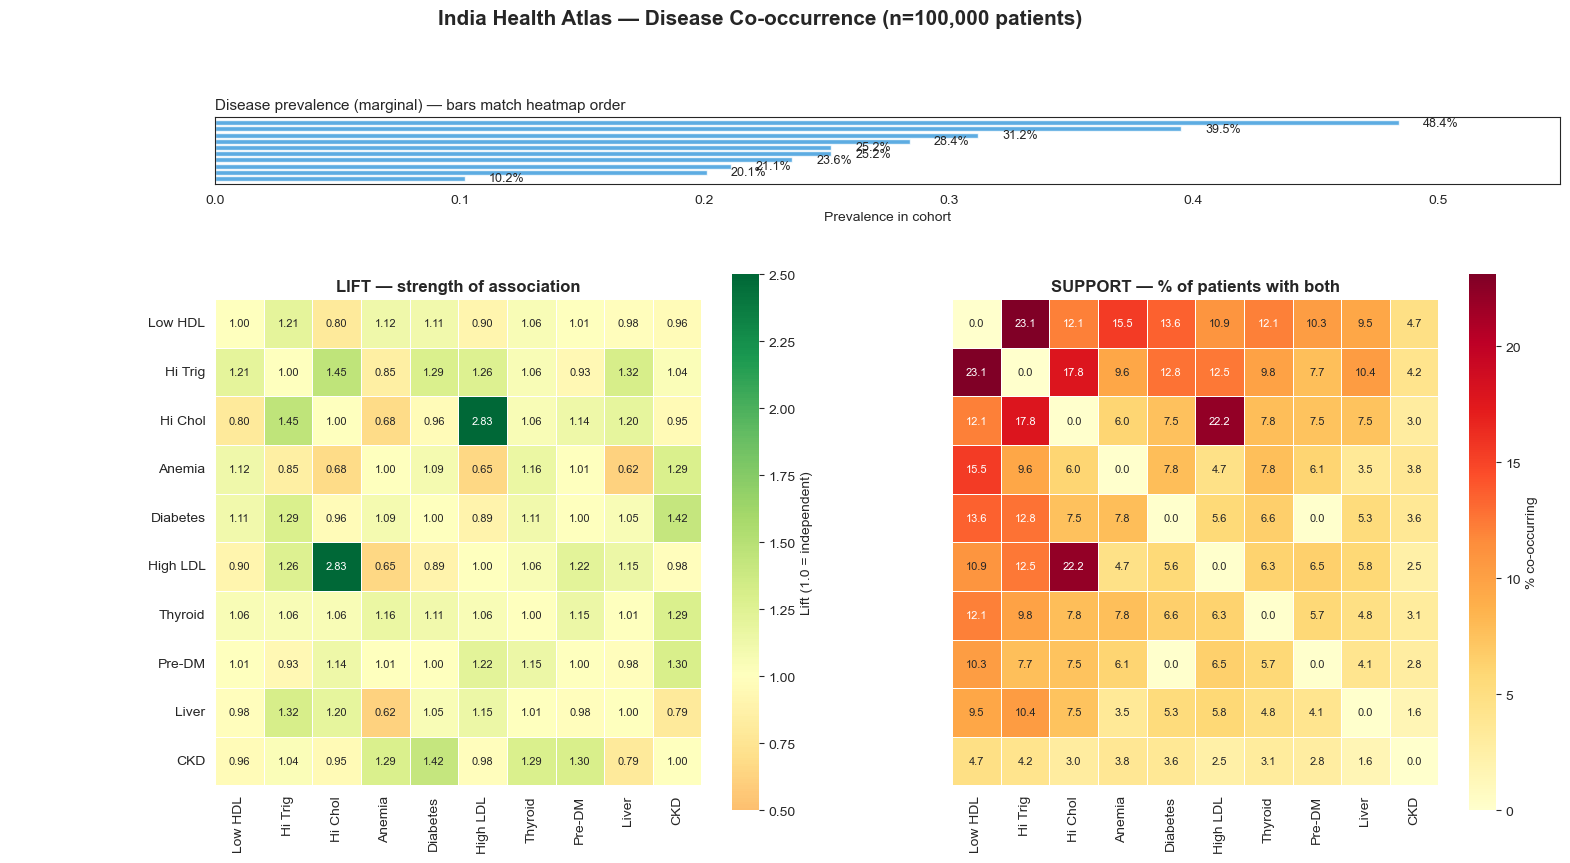

Saved -> E:/NidaanKosha-100k/reports/figures/02_cooccurrence_heatmap.png
Conditions: 10    Pairs analyzed: 44


In [29]:
# ---------- Phase 7b: co-occurrence heatmap (fixed) ----------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
cooc = pd.read_csv(r"E:/NidaanKosha-100k/data/processed/disease_cooccurrence.csv")
# Disease short labels for readability
LABELS = {
    "anemia": "Anemia", "diabetes": "Diabetes", "prediabetes": "Pre-DM",
    "high_cholesterol": "Hi Chol", "high_triglycerides": "Hi Trig",
    "low_hdl": "Low HDL", "high_ldl": "High LDL",
    "thyroid_disorder": "Thyroid", "liver_issue": "Liver", "ckd": "CKD",
}
PREV = {
    "anemia": 0.284, "diabetes": 0.252, "prediabetes": 0.211,
    "high_cholesterol": 0.312, "high_triglycerides": 0.395,
    "low_hdl": 0.484, "high_ldl": 0.252,
    "thyroid_disorder": 0.236, "liver_issue": 0.201, "ckd": 0.102,
}
# Build symmetric NxN lift matrix (numpy, no pandas views)
nodes = sorted(set(cooc.condition_a) | set(cooc.condition_b))
n = len(nodes)
idx = {name: i for i, name in enumerate(nodes)}
lift = np.ones((n, n), dtype=float)         # diagonal = 1.0
support = np.zeros((n, n), dtype=float)     # diagonal = 0.0
for _, r in cooc.iterrows():
    i, j = idx[r.condition_a], idx[r.condition_b]
    lift[i, j] = r["lift"]
    lift[j, i] = r["lift"]
    support[i, j] = r["pct_of_a"]
    support[j, i] = r["pct_of_b"]
# Sort nodes by prevalence (most common first)
order = sorted(range(n), key=lambda i: -PREV.get(nodes[i], 0))
nodes_sorted = [nodes[i] for i in order]
labels = [LABELS.get(n, n) for n in nodes_sorted]
lift_s      = lift[np.ix_(order, order)].copy()
support_s   = support[np.ix_(order, order)].copy()
lift_clip   = np.clip(lift_s, None, 3.0)     # cap at 3 for color
# Marginal prevalence strip
marg = np.array([PREV.get(n, 0) for n in nodes_sorted])
# --- Figure ---
sns.set_style("white")
fig = plt.figure(figsize=(20, 9))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 8, 8], height_ratios=[1, 8],
                      wspace=0.3, hspace=0.3)
# Top marginal bar
ax_top = fig.add_subplot(gs[0, 1:])
ax_top.barh(labels, marg, color="#3498db", alpha=0.8, edgecolor="white")
ax_top.set_xlim(0, 0.55)
ax_top.invert_yaxis()
ax_top.set_yticks([])
ax_top.set_xlabel("Prevalence in cohort")
ax_top.set_title("Disease prevalence (marginal) — bars match heatmap order",
                 fontsize=11, loc="left")
for i, v in enumerate(marg):
    ax_top.text(v + 0.01, i, f"{v*100:.1f}%", va="center", fontsize=9)
# Heatmap 1: LIFT
ax1 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    lift_clip, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0,
    vmin=0.5, vmax=2.5, square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Lift (1.0 = independent)"},
    xticklabels=labels, yticklabels=labels, ax=ax1, annot_kws={"size": 8}
)
ax1.set_title("LIFT — strength of association", fontsize=12, fontweight="bold")
# Heatmap 2: SUPPORT
ax2 = fig.add_subplot(gs[1, 2])
sns.heatmap(
    support_s, annot=True, fmt=".1f", cmap="YlOrRd",
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "% co-occurring"},
    xticklabels=labels, yticklabels=[], ax=ax2, annot_kws={"size": 8}
)
ax2.set_title("SUPPORT — % of patients with both", fontsize=12, fontweight="bold")
# Hide the empty top-left corner
fig.add_subplot(gs[0, 0]).axis("off")
plt.suptitle("India Health Atlas — Disease Co-occurrence (n=100,000 patients)",
             fontsize=15, fontweight="bold", y=1.00)
out = r"E:/NidaanKosha-100k/reports/figures/02_cooccurrence_heatmap.png"
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved -> {out}")
print(f"Conditions: {n}    Pairs analyzed: {len(cooc)}")